In [2]:
import os
import sys
import glob
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import ultralytics
from ultralytics import YOLO

# Print environment details to verify setup
print(f"Python Version: {sys.version.split()[0]}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
print(f"Ultralytics Version: {ultralytics.__version__}")

Python Version: 3.12.0
PyTorch Version: 2.14.0+cpu
CUDA Available: False
Ultralytics Version: 8.4.165


In [3]:
# Base paths
DATASET_DIR = Path(r"C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data")
YAML_PATH = DATASET_DIR / "data.yaml"

TRAIN_IMG_DIR = DATASET_DIR / "train" / "images"
TRAIN_LBL_DIR = DATASET_DIR / "train" / "labels"
TEST_IMG_DIR = DATASET_DIR / "test" / "images"
TEST_LBL_DIR = DATASET_DIR / "test" / "labels"

# Verify directories exist
paths_to_check = [DATASET_DIR, YAML_PATH, TRAIN_IMG_DIR, TRAIN_LBL_DIR, TEST_IMG_DIR, TEST_LBL_DIR]
for p in paths_to_check:
    status = "EXISTS" if p.exists() else "NOT FOUND"
    print(f"[{status}] {p}")

[EXISTS] C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data
[EXISTS] C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data\data.yaml
[EXISTS] C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data\train\images
[EXISTS] C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data\train\labels
[EXISTS] C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data\test\images
[EXISTS] C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data\test\labels


In [4]:
train_imgs = list(TRAIN_IMG_DIR.glob("*.png"))
train_lbls = list(TRAIN_LBL_DIR.glob("*.txt"))
test_imgs = list(TEST_IMG_DIR.glob("*.png"))
test_lbls = list(TEST_LBL_DIR.glob("*.txt"))

print("=== Dataset Summary ===")
print(f"Train Images: {len(train_imgs)} (Expected: 346)")
print(f"Train Labels: {len(train_lbls)} (Expected: 346)")
print(f"Test Images:  {len(test_imgs)}  (Expected: 87)")
print(f"Test Labels:   {len(test_lbls)}  (Expected: 87)")

# Inspect a sample annotation file
if train_lbls:
    sample_txt = train_lbls[0]
    with open(sample_txt, "r") as f:
        content = f.read().strip()
    print(f"\nSample annotation file ({sample_txt.name}):")
    print(f"Content: {content}")

=== Dataset Summary ===
Train Images: 277 (Expected: 346)
Train Labels: 277 (Expected: 346)
Test Images:  87  (Expected: 87)
Test Labels:   87  (Expected: 87)

Sample annotation file (Cars0.txt):
Content: 0 0.645 0.5559701492537313 0.38599999999999995 0.17910447761194032


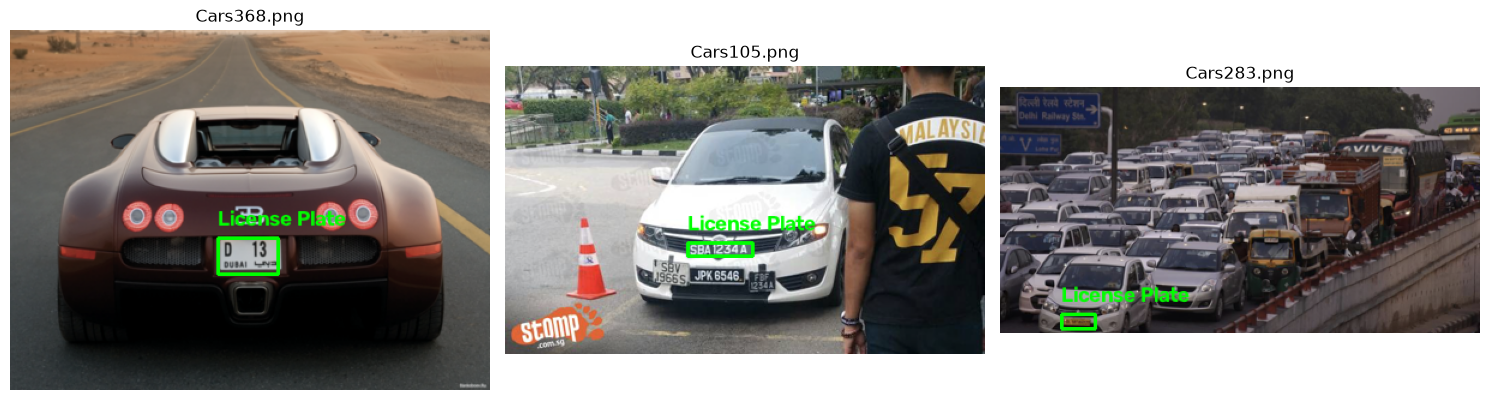

In [5]:
def draw_yolo_bbox(img_path, label_path):
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = image.shape

    if label_path.exists():
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = map(float, parts)
                # Convert normalized YOLO coordinates back to pixel bounding box coordinates
                x1 = int((xc - w / 2) * w_img)
                y1 = int((yc - h / 2) * h_img)
                x2 = int((xc + w / 2) * w_img)
                y2 = int((yc + h / 2) * h_img)

                # Draw bounding box and label
                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(image, "License Plate", (x1, max(y1 - 10, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    return image

# Pick 3 random images from the training set and display them with annotations
sample_images = random.sample(train_imgs, 3)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_p in zip(axes, sample_images):
    lbl_p = TRAIN_LBL_DIR / f"{img_p.stem}.txt"
    annotated_img = draw_yolo_bbox(img_p, lbl_p)
    ax.imshow(annotated_img)
    ax.set_title(img_p.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Initialize YOLO11 Nano pre-trained weights
model = YOLO("yolo11n.pt")
print("Model initialized successfully.")

Model initialized successfully.


In [7]:
import os
import shutil
import random
from pathlib import Path

# Paths
TRAIN_IMG = DATASET_DIR / "train" / "images"
TRAIN_LBL = DATASET_DIR / "train" / "labels"

VAL_IMG = DATASET_DIR / "val" / "images"
VAL_LBL = DATASET_DIR / "val" / "labels"

# Create val directories if they don't exist
VAL_IMG.mkdir(parents=True, exist_ok=True)
VAL_LBL.mkdir(parents=True, exist_ok=True)

# Select 20% of training images randomly
all_train_imgs = list(TRAIN_IMG.glob("*.png"))
val_count = int(len(all_train_imgs) * 0.2)
random.seed(42)
val_selected_imgs = random.sample(all_train_imgs, val_count)

# Move selected images and corresponding label files to val/
for img_path in val_selected_imgs:
    lbl_path = TRAIN_LBL / f"{img_path.stem}.txt"
    
    # Move image
    shutil.move(str(img_path), str(VAL_IMG / img_path.name))
    
    # Move label if it exists
    if lbl_path.exists():
        shutil.move(str(lbl_path), str(VAL_LBL / lbl_path.name))

print(f"Moved {len(val_selected_imgs)} images and labels to validation set.")
print(f"Remaining training images: {len(list(TRAIN_IMG.glob('*.png')))}")
print(f"Validation images: {len(list(VAL_IMG.glob('*.png')))}")

Moved 55 images and labels to validation set.
Remaining training images: 222
Validation images: 124


In [8]:
import torch
from ultralytics import YOLO

if __name__ == "__main__":
    # 1. Initialize fresh weights
    model = YOLO("yolo11n.pt")

    # 2. Configure PyTorch to use all CPU threads for intra-op matrix multiplication
    num_threads = torch.get_num_threads()
    print(f"PyTorch using {num_threads} CPU execution threads.")

    # 3. Train with parallel data loading workers
    results = model.train(
        data=str(YAML_PATH),
        epochs=20,
        imgsz=640,
        batch=16,
        patience=10,
        workers=4,          # Enables 4 CPU background workers for parallel data pre-fetching
        project=str(DATASET_DIR / "runs"),
        name="license_plate_run",
        exist_ok=True,
        seed=42
    )

    CHECKPOINT_PATH = DATASET_DIR / "runs" / "license_plate_run" / "weights" / "best.pt"
    print(f"\nTraining Complete!")
    print(f"Custom model weights saved at: {CHECKPOINT_PATH}")

PyTorch using 12 CPU execution threads.


Ultralytics 8.4.165  Python-3.12.0 torch-2.14.0+cpu CPU (12th Gen Intel Core i7-12700)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_plate_run, nbs=